# Do "Camarilla pivots" actually stop the market? 🧱
### Magic support/resistance lines from yesterday's range — tested against a coin-flip

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Line_is_special%3F: Busted](https://img.shields.io/badge/Line_is_special%3F-Busted-8b949e?style=flat-square)

Open any day-trading forum and you'll meet the **Camarilla pivots**: a ladder of lines you compute each morning from *yesterday's* high, low and close. The headline lines — **L3** and **H3** — are sold as near-magical support and resistance. The pitch: when price drops to **L3**, it *bounces*; when it rises to **H3**, it *rolls over*. So you fade them back toward the middle and collect.

It's a lovely story. It also makes a sharp, testable promise: **price should respect these specific lines more than it respects a line drawn anywhere else.** That's exactly the kind of claim that usually evaporates the moment you compare it to a random line — and charge the spread you'd really pay trading every five minutes.

> 📓 **Plain-language layer.** Want the *t*-stats, the HAC correction and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A loud data caveat.** Intraday history on free data is *short* — Yahoo gives ~60 days of 5-minute bars. So this is **5 liquid names over ~59 sessions**, a thin power budget; we pool across names and lean on a random-line placebo. Every chart is drawn by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from camarilla_pivots import data, strategy as st

def _load_trimmed():
    frames = data.load_real()
    out = {}
    for t, b in frames.items():
        last = b["session"].max()                 # drop the in-progress final session
        out[t] = b[b["session"] < last].copy()
    return out

HAVE_REAL = data.have_real()
if HAVE_REAL:
    FRAMES = _load_trimmed()
    EV = pd.concat([st.collect_events(b).assign(ticker=t) for t, b in FRAMES.items()],
                   ignore_index=True)
    CTRL = pd.concat([st.collect_random_controls(b, n_draws=50) for b in FRAMES.values()],
                     ignore_index=True)
else:
    FRAMES = EV = CTRL = None
print("real intraday cache present:", HAVE_REAL,
      "| events:", (0 if EV is None else len(EV)),
      "| names:", (0 if FRAMES is None else len(FRAMES)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2026-03-30', 'end': '2026-06-23', 'sessions': 59, 'n_names': 5, 'interval': '5m', 'n_events': 363, 'name_days': 289, 'ctrl_n': 27442, 'fingerprint': '36705730ed53', 'rev': -0.0173, 't': -0.444, 'hac_t': -2.59, 'hit': 0.482, 'ctrl_mean': 0.2498, 'diff': -0.2671, 'diff_p': 1.0, 'net': -0.0573, 'cost_bps': 2.0, 'by_level': [('L3', 161, 0.0194, 0.32, 0.54), ('H3', 202, -0.0466, -0.92, 0.436)], 'hold': [(6, 363, -0.0221, -0.72), (12, 363, -0.0173, -0.44), (24, 358, -0.0906, -1.85)], 'by_tk': [('SPY', 77, 0.0318, 0.96), ('QQQ', 74, -0.0268, -0.52), ('AAPL', 72, -0.0623, -0.84), ('MSFT', 70, -0.0062, -0.06), ('NVDA', 70, -0.0263, -0.19)], 'syn': [(0.0, 51, -0.0316, -0.59, -1.15, 0.51, 0.1196, -0.1513, 0.998), (0.5, 69, 0.2139, 6.86, 11.94, 0.797, 0.1302, 0.0837, 0.003)]}


real intraday cache present: True | events: 363 | names: 5


## The answer first

| Question | Answer |
|---|---|
| When price touches **L3/H3**, does it bounce back toward the middle? | **No.** Across 363 touches the average reversion is **-0.017%** — a hair *below* zero. A coin flip. |
| Is an L3/H3 line **more special** than a random line at the same distance? | **No — the opposite.** Random control lines reverted **+0.25%** on average, *better* than the "magic" levels. The line isn't special; the geometry is. |
| After costs? | **Negative.** Trading the bounce costs the spread twice; net it's **-0.057%** per touch — you pay to play. |
| Can our test detect a *real* level if one existed? | **Yes.** On synthetic data where we *plant* genuine respect-the-level behaviour, the same test lights up hard (next notebook). It finds nothing here because there's nothing to find. |

> The Camarilla ladder is just arithmetic on yesterday's range. Price crosses those numbers the way it crosses any number — no more, no less.

## 1 · The claim

> *"Take yesterday's high, low and close. Camarilla math gives you four lines above and four below. **L3** and **H3** are the reversal lines: price respects them. Fade L3 long and H3 short back toward the central pivot — and when price blows clean through **L4/H4**, it breaks out and runs."*

The exact recipe (the multipliers are fixed lore): with range `R = high − low`,

`H3 = close + R × 1.1/4`,  `L3 = close − R × 1.1/4`,  `H4/L4 = close ± R × 1.1/2`,  central pivot `P = (high+low+close)/3`.

Nick Scott popularised the Camarilla equation in the late 1980s; it's now baked into every charting platform. The promise is specific and falsifiable — which is all we need.

## 2 · So what?

If L3/H3 really were support and resistance, you'd have a tidy intraday machine: fade the touch, target the pivot, repeat daily. Thousands of traders believe exactly this and place their stops and entries on these lines — which is *itself* a reason it might (briefly) self-fulfill.

But there are two traps. **(1)** Any horizontal line a volatile price wanders into will sometimes "bounce" — that's just mean-reversion-by-geometry, not a property of *that* line. The honest test isn't "does L3 bounce?" but "does L3 bounce **more than a random line**?" **(2)** Intraday edges are tiny, and you'd trade them constantly — the bid/ask spread, paid on every round trip, is where intraday strategies go to die.

## 3 · How would we even know?

We pull **5-minute bars** for **5 very liquid names** (SPY, QQQ, AAPL, MSFT, NVDA) over **~59 sessions** — the best case for an intraday edge (deep books, tight spreads). For each session:

1. Compute today's Camarilla ladder from **yesterday's** H/L/C (known at the open — no look-ahead).
2. Find the **first** 5-minute bar that touches **L3** (a long candidate) or **H3** (a short candidate).
3. Enter the **next** bar (one-bar lag), hold ~1 hour, and measure the reversion **toward the central pivot**. Positive = the level was respected.
4. **The placebo:** run the *identical* rule on **random lines** placed at the same distance from the open. If the magic lines don't beat random lines, the magic is busted.

**What would make us say "mirage":** reversion near zero, no better than the random control, and negative after costs. (Spoiler: that's exactly what we find.)

## 4 · The teardown — let's actually look

**First: when price touches L3/H3, does it revert?** Here's the average forward reversion per level, with the coin-flip line at zero.

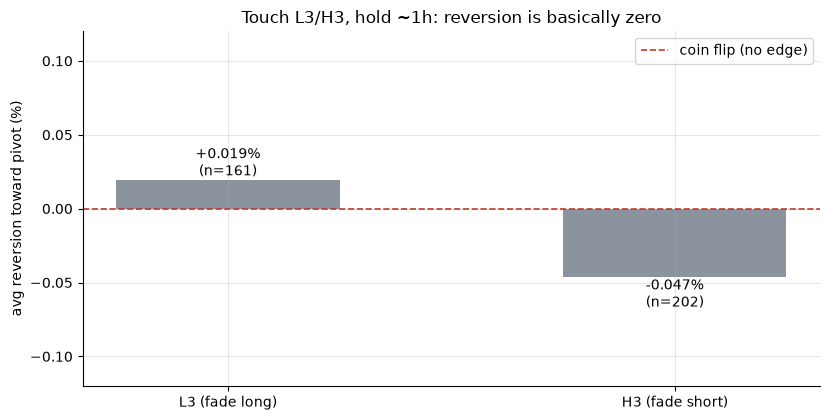

L3: +0.019%  H3: -0.047%


In [2]:
if HAVE_REAL:
    vals = [EV[EV.level==l]['rev'].values.mean()*100 for l in ['L3','H3']]
    ns   = [int((EV.level==l).sum()) for l in ['L3','H3']]
else:
    vals = [R['by_level'][0][2], R['by_level'][1][2]]; ns=[R['by_level'][0][1], R['by_level'][1][1]]
fig, ax = plt.subplots(figsize=(8.4, 4.3))
ax.bar(['L3 (fade long)','H3 (fade short)'], vals, color=[GREY,GREY], width=.5)
for i,v in enumerate(vals): ax.annotate(f'{v:+.3f}%\n(n={ns[i]})',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.axhline(0, c=RED, lw=1.2, ls='--', label='coin flip (no edge)')
ax.set_ylabel('avg reversion toward pivot (%)'); ax.set_ylim(-0.12,0.12)
ax.set_title('Touch L3/H3, hold ~1h: reversion is basically zero'); ax.legend()
plt.tight_layout(); plt.show()
print('L3:', f'{vals[0]:+.3f}%', ' H3:', f'{vals[1]:+.3f}%')

Nothing. L3 reverts a trivial **+0.019%**, H3 actually goes the *wrong* way (**-0.047%**). Both sit on top of the coin-flip line. The levels do not behave like support and resistance.

**Now the decisive comparison.** Maybe *any* line bounces a little. So we drew **thousands of random control lines** at the same distance and ran the identical rule. If L3/H3 were special, the green (real) bar would tower over the grey (random) one.

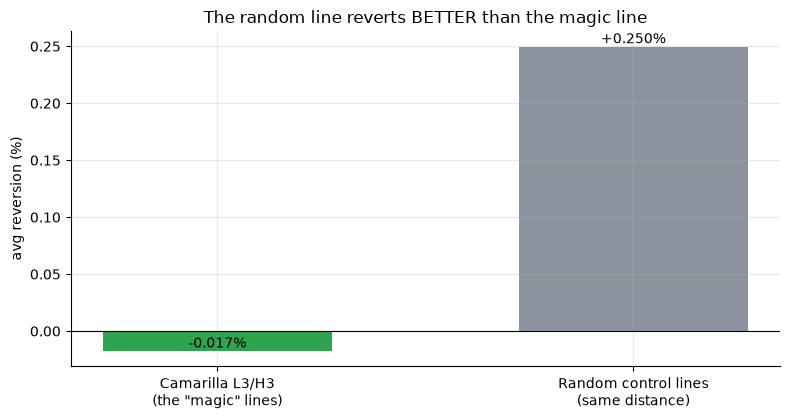

real: -0.017%  random control: +0.250%  (real beats control?  False )


In [3]:
if HAVE_REAL:
    real = EV['rev'].values.mean()*100
    ctrl = CTRL['rev'].values.mean()*100
else:
    real = R['rev']; ctrl = R['ctrl_mean']
fig, ax = plt.subplots(figsize=(8.0, 4.3))
ax.bar(['Camarilla L3/H3\n(the "magic" lines)','Random control lines\n(same distance)'],
       [real, ctrl], color=[GREEN, GREY], width=.55)
for i,v in enumerate([real,ctrl]): ax.annotate(f'{v:+.3f}%',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('avg reversion (%)')
ax.set_title('The random line reverts BETTER than the magic line')
plt.tight_layout(); plt.show()
print('real:', f'{real:+.3f}%', ' random control:', f'{ctrl:+.3f}%', ' (real beats control? ',(real>ctrl),')')

This is the whole study in one chart. The **random** lines reverted **+0.25%** — *better* than the Camarilla lines (**-0.017%**). Whatever tiny mean-reversion exists intraday belongs to *any* line price wanders into, not to these specific numbers. The Camarilla levels aren't special; they're decoration on top of plain geometry.

## 5 · The verdict

- **Signal — None.** Reversion off L3/H3 is **~0** and *worse* than a random line. No edge.
- **Tradability — Mirage.** Even the tiny number turns **negative after the spread** you'd pay trading every touch.
- **"The line is special"? — Busted.** A randomly-placed line reverts at least as well. The lore is arithmetic dressed up as physics.

## 6 · Could you actually trade it? — the spread eats it alive

Suppose you ignored all of the above and traded the bounce anyway. Every touch is a fresh round trip; on intraday names you pay the bid/ask spread **twice**. Here's gross vs net.

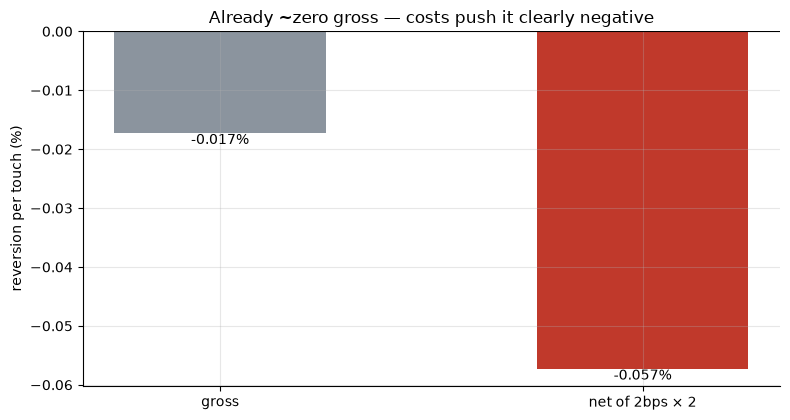

gross: -0.017%  net: -0.057%


In [4]:
if HAVE_REAL:
    gross = EV['rev'].values.mean()*100
    net = (EV['rev'].values.mean() - 2*R['cost_bps']/1e4)*100
else:
    gross = R['rev']; net = R['net']
fig, ax = plt.subplots(figsize=(8.0, 4.3))
ax.bar(['gross','net of 2bps × 2'], [gross, net], color=[GREY, RED], width=.5)
for i,v in enumerate([gross,net]): ax.annotate(f'{v:+.3f}%',(i,v),ha='center',va='top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('reversion per touch (%)')
ax.set_title('Already ~zero gross — costs push it clearly negative')
plt.tight_layout(); plt.show()
print('gross:', f'{gross:+.3f}%', ' net:', f'{net:+.3f}%')

Gross is already a rounding error; net of a modest **2 bps** round-trip it's **-0.057%** per touch. And that's on the *most* liquid names with the *tightest* spreads — on anything thinner it's worse. There is no version of this that pays.

## 7 · Going further 🚪

- **More data would help a little, not much.** 60 days of 5-minute bars is thin; a paid feed with years of history could tighten the error bars — but the *random control already beats the real level*, so more data is unlikely to rescue it.
- **Self-fulfilling at the open?** A fun fork: do the lines work *only* in the first 15 minutes, when order flow clusters on published levels? Test the touch-time conditionality.
- **The general lesson.** Any indicator that produces *lines* invites this exact test: does the line beat a random line? It's the cleanest placebo in technical analysis, and most drawn-line systems fail it.

*Think the Camarilla edge is real? Show the L3/H3 reversion beating its **random twin** after costs, on out-of-sample names — then we'll talk.*